## **Deteksi outlier pada data iris**

## **Pengumpulan Data**
Dataset **IRIS** adalah Dataset ini berisi informasi tentang tiga spesies bunga Iris (*Setosa, Versicolor, Virginica*), dengan empat fitur utama: panjang dan lebar sepal serta panjang dan lebar petal.

---
#### **Lokasi Data**
Data **IRIS** yang digunakan berada dalam cloud data platform **aiven** dan **Dbeaver** untuk kelola database :
- Data IRIS petal berada di database  **MySQL**.
- Data IRIS sepal berada di database  **PostgreSQL**.

---
#### **Metode Pengumpulan Data**
Langkah pengumpulan data dilakukan dengan Python menggunakan pustaka berikut:  

1. **pymysql** → Untuk menghubungkan dan mengambil data dari MySQL.  
2. **pandas** → Untuk membaca dan mengolah data setelah diambil dari database.  
3. **psycopg2-binary** → Untuk menghubungkan dan mengambil data dari PostgreSQL.  
4. **sqlalchemy** → Untuk membuat koneksi database yang lebih stabil dan kompatibel dengan `pandas.read_sql()`.  
5. **python-dotenv** → Untuk menyimpan kredensial database dalam file `.env` agar lebih aman dan tidak perlu hardcoding dalam kode Python.
---
#### **Cara Mengumpulkan Data**

##### **1. Menghubungkan ke MySQL dan PostgreSQL**
- Install library python yang diperlukan




In [1]:
!pip install pymysql
!pip install pandas
!pip install psycopg2-binary
!pip install sqlalchemy
!pip install python-dotenv



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 18.0 MB/s eta 0:00:00


- buat file env untuk koneksi database di aiven anda.


Sesuaikan seperti format dibawah ini:
```python
# Database MySQL
MYSQL_HOST=<HOSTNAME>
MYSQL_USER=<USERNAME>
MYSQL_PASSWORD=<PASSWORD>
MYSQL_PORT=<PORT>
MYSQL_DATABASE=<DATABASE_NAME>

# Database PostgreSQL
PG_HOST=<HOSTNAME>
PG_USER=<USERNAME>
PG_PASSWORD=<PASSWORD>
PG_PORT=<PORT>
PG_DATABASE=<DATABASE_NAME>
```

Upload env:

In [2]:
from google.colab import files
uploaded = files.upload()

Saving .env to .env


- koneksikan database di aiven

In [4]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

# Ambil variabel koneksi dari lingkungan
MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_PORT = os.getenv("MYSQL_PORT")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

PG_HOST = os.getenv("PG_HOST")
PG_PORT = os.getenv("PG_PORT")
PG_USER = os.getenv("PG_USER")
PG_PASSWORD = os.getenv("PG_PASSWORD")
PG_DATABASE = os.getenv("PG_DATABASE")

# Gunakan SQLAlchemy untuk koneksi ke MySQL
mysql_engine = create_engine(f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}")

# Gunakan SQLAlchemy untuk koneksi ke PostgreSQL
pg_engine = create_engine(f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DATABASE}")


##### **2. Mengambil dan menampilkan data**

In [5]:
try:
    # Query MySQL
    mysql_query = "SELECT * FROM petal_data;"
    df_mysql = pd.read_sql(mysql_query, mysql_engine)

    # Query PostgreSQL
    pg_query = "SELECT * FROM sepal_data;"
    df_postgres = pd.read_sql(pg_query, pg_engine)

    # Print hasil query
    print("Data dari MySQL:")
    print(df_mysql.to_string())

    print("\nData dari PostgreSQL:")
    print(df_postgres.to_string())

    # Jika data berhasil diambil, hapus file .env
    if os.path.exists(".env"):
        os.remove(".env")

except Exception as e:
    print(f"Gagal mengambil data: {e}")

Data dari MySQL:
      id            Class  petal length  petal width
0      1      Iris-setosa          86.4         70.0
1      2      Iris-setosa           1.4          0.2
2      3      Iris-setosa           1.3          0.2
3      4      Iris-setosa           1.5          0.2
4      5      Iris-setosa           1.4          0.2
5      6      Iris-setosa           1.7          0.4
6      7      Iris-setosa           1.4          0.3
7      8      Iris-setosa           1.5          0.2
8      9      Iris-setosa           1.4          0.2
9     10      Iris-setosa           1.5          0.1
10    11      Iris-setosa           1.5          0.2
11    12      Iris-setosa           1.6          0.2
12    13      Iris-setosa           1.4          0.1
13    14      Iris-setosa           1.1          0.1
14    15      Iris-setosa           1.2          0.2
15    16      Iris-setosa           1.5          0.4
16    17      Iris-setosa           1.3          0.4
17    18      Iris-setosa    


##### **3. Menggabungkan Data dari Kedua Database**



In [6]:
# Menggabungkan data dari MySQL (df_mysql) dan PostgreSQL (df_postgres) berdasarkan kolom 'id'
df_combined = pd.merge(
    df_mysql,  # Data dari MySQL yang berisi informasi petal
    df_postgres.drop(columns=['Class']),  # Menghapus kolom 'Class' dari df_postgres sebelum penggabungan
    on="id",  # Menggabungkan berdasarkan kolom 'id' yang harus ada di kedua dataframe
    how="inner"  # Menggunakan inner join, hanya menyertakan data dengan 'id' yang ada di kedua tabel
)

# Menampilkan hasil penggabungan
print("\nData gabungan:")
print(df_combined.to_string())



Data gabungan:
      id            Class  petal length  petal width  sepal length  sepal width
0      1      Iris-setosa          86.4         70.0          20.1         30.5
1      2      Iris-setosa           1.4          0.2           4.9          3.0
2      3      Iris-setosa           1.3          0.2           4.7          3.2
3      4      Iris-setosa           1.5          0.2           4.6          3.1
4      5      Iris-setosa           1.4          0.2           5.0          3.6
5      6      Iris-setosa           1.7          0.4           5.4          3.9
6      7      Iris-setosa           1.4          0.3           4.6          3.4
7      8      Iris-setosa           1.5          0.2           5.0          3.4
8      9      Iris-setosa           1.4          0.2           4.4          2.9
9     10      Iris-setosa           1.5          0.1           4.9          3.1
10    11      Iris-setosa           1.5          0.2           5.4          3.7
11    12      Iris-setos

---
# K-Nearest Neighbors (KNN)

## Apa itu KNN?
K-Nearest Neighbors (KNN) adalah salah satu algoritma dalam machine learning yang digunakan untuk klasifikasi dan regresi. Algoritma ini bekerja dengan mencari sejumlah tetangga terdekat (K) dari sebuah data uji berdasarkan jarak tertentu. KNN adalah metode berbasis instance, yang berarti ia tidak mempelajari model eksplisit, tetapi membuat prediksi berdasarkan kedekatan dengan data yang sudah ada.

## Alur Kerja KNN
1. **Menentukan jumlah tetangga (K) terdekat**:
   - Nilai K adalah parameter utama dalam KNN yang harus ditentukan terlebih dahulu.
   - Nilai K yang terlalu kecil dapat membuat model terlalu sensitif terhadap noise, sementara nilai K yang terlalu besar dapat mengaburkan batas antara kelas.
   - Pemilihan nilai K biasanya dilakukan melalui eksperimen atau validasi silang.

2. **Menghitung jarak antara data uji dan seluruh data latih**:
   - Untuk menentukan kedekatan antara data uji dan data latih, digunakan beberapa metode perhitungan jarak:
     - **Jarak Euclidean** (umum digunakan untuk data kontinu):

         $d(x, y)=\sqrt{\sum_{i=1}^n\left(x_i-y_i\right)^2}$
     - **Jarak Manhattan** (cocok untuk data dengan fitur kategori):

         $\mathrm{d}=\sum_{i=1}^n\left|\mathbf{x}_i-\mathbf{y}_i\right|$
     - **Jarak Minkowski** (generalisasi Euclidean dan Manhattan):
     
         $\left(\sum_{i=1}^n\left|x_i-y_i\right|^p\right)^{1 / p}$

3. **Mengurutkan data latih berdasarkan jarak terdekat dengan data uji**:
   - Setelah menghitung jarak antara data uji dengan semua data latih, kita mengurutkan data latih dari yang paling dekat hingga yang paling jauh.
   - Pengurutan ini penting untuk menentukan K tetangga terdekat secara akurat.

4. **Memilih K tetangga terdekat**:
   - Dari hasil pengurutan, kita ambil K data dengan jarak paling kecil.
   - Pemilihan K tetangga ini akan menentukan keputusan klasifikasi.

5. **Menghitung frekuensi masing-masing kategori pada K data yang telah dipilih**:
   - Jika tugasnya adalah klasifikasi, maka dihitung jumlah data dari setiap kategori yang ada di antara K tetangga terdekat.
   - Jika tugasnya adalah regresi, maka rata-rata nilai dari K tetangga digunakan untuk prediksi.

6. **Menentukan kelas berdasarkan kategori dengan frekuensi tertinggi**:
   - Data uji diklasifikasikan berdasarkan kategori mayoritas dari K tetangga terdekat.
   - Jika ada hasil yang seri, strategi tambahan seperti memilih berdasarkan bobot jarak dapat digunakan.

## Contoh Kasus
Misalkan kita memiliki dataset dengan fitur "Tinggi (cm)" dan "Berat (kg)" untuk mengklasifikasikan seseorang sebagai "Atlet" atau "Non-Atlet".

| Tinggi (cm) | Berat (kg) | Kelas |
|-------------|-----------|-------|
| 170         | 65        | Atlet |
| 160         | 70        | Non-Atlet |
| 180         | 80        | Atlet |
| 175         | 75        | Atlet |
| 165         | 68        | Non-Atlet |

Jika ada data baru dengan **Tinggi = 172 cm** dan **Berat = 72 kg**, kita akan menerapkan alur kerja KNN:

1. **Menentukan jumlah tetangga (K) terdekat**: Misalkan kita memilih **K = 3**.
2. **Menghitung jarak antara data uji dan seluruh data latih** (menggunakan Jarak Euclidean sebagai contoh):

   $d(170, 65) = \sqrt{(172 - 170)^2 + (72 - 65)^2} \approx 7.28$

   $d(160, 70) = \sqrt{(172 - 160)^2 + (72 - 70)^2} \approx 12.17$

   $d(180, 80) = \sqrt{(172 - 180)^2 + (72 - 80)^2} \approx 11.31$

   $d(175, 75) = \sqrt{(172 - 175)^2 + (72 - 75)^2} \approx 4.24$

   $d(165, 68) = \sqrt{(172 - 165)^2 + (72 - 68)^2} \approx 8.06$


3. **Mengurutkan data latih berdasarkan jarak terdekat**:
   
   | Data Latih (Tinggi, Berat) | Hasil Jarak | Kelas |
   |---------------------------|-------------|-------|
   | (175, 75)                 | 4.24        | Atlet |
   | (170, 65)                 | 7.28        | Atlet |
   | (165, 68)                 | 8.06        | Non-Atlet |
   | (180, 80)                 | 11.31       | Atlet |
   | (160, 70)                 | 12.17       | Non-Atlet |
   


4. **Memilih 3 tetangga terdekat**: (175, 75) → Atlet, (170, 65) → Atlet, (165, 68) → Non-Atlet.

5. **Menghitung frekuensi masing-masing kategori**:
   - Atlet: 2
   - Non-Atlet: 1
6. **Menentukan kelas berdasarkan mayoritas**: Karena **Atlet memiliki frekuensi tertinggi (2 dari 3)**, maka data baru diklasifikasikan sebagai **Atlet**.

Dengan menggunakan algoritma KNN, kita berhasil memprediksi bahwa seseorang dengan tinggi 172 cm dan berat 72 kg masuk dalam kategori **Atlet** berdasarkan data yang tersedia.



#### **Implementasi KNN pada data iris**
##### **1. Menghitung jarak menggunakan Euclidean Distance**

In [ ]:
# Import library untuk menemukan tetangga terdekat (KNN)
from sklearn.neighbors import NearestNeighbors

X = df_combined.drop(columns=['id', 'Class'])
# Inisialisasi model KNN
K = 3  # Gunakan 3 tetangga terdekat
knn = NearestNeighbors(n_neighbors=K)
knn.fit(X)

# Menghitung jarak ke 5 tetangga terdekat
distances, indices = knn.kneighbors(X)

# Hitung rata-rata jarak ke tetangga terdekat
mean_distances = distances.mean(axis=1)

# Buat salinan dataframe agar df_combined tidak berubah
df_knn_outlier = df_combined.copy()

# Menambahkan kolom rata-rata jarak ke K tetangga terdekat
df_knn_outlier["mean_distance"] = mean_distances

# Menampilkan beberapa baris pertama
print(df_knn_outlier.to_string())



      id            Class  petal length  petal width  sepal length  sepal width  mean_distance
0      1      Iris-setosa          86.4         70.0          20.1         30.5      72.497181
1      2      Iris-setosa           1.4          0.2           4.9          3.0       0.094281
2      3      Iris-setosa           1.3          0.2           4.7          3.2       0.128790
3      4      Iris-setosa           1.5          0.2           4.6          3.1       0.104875
4      5      Iris-setosa           1.4          0.2           5.0          3.6       0.115470
5      6      Iris-setosa           1.7          0.4           5.4          3.9       0.226024
6      7      Iris-setosa           1.4          0.3           4.6          3.4       0.162727
7      8      Iris-setosa           1.5          0.2           5.0          3.4       0.080474
8      9      Iris-setosa           1.4          0.2           4.4          2.9       0.147140
9     10      Iris-setosa           1.5          0

##### **2. Menentukan Threshold Outlier**
Gunakan persentil 95% sebagai batas atas untuk mendeteksi outlier. Data dengan mean_distance lebih tinggi dari threshold akan dianggap outlier.

In [ ]:
import numpy as np

# Menentukan threshold outlier berdasarkan kuantil 95%
threshold = np.percentile(mean_distances, 95)

# Menambahkan kolom baru untuk menandai apakah data termasuk outlier
df_knn_outlier["is_outlier"] = df_knn_outlier["mean_distance"] > threshold

# Menampilkan jumlah data yang terdeteksi sebagai outlier
print("Jumlah outlier terdeteksi:")
print(df_knn_outlier["is_outlier"].value_counts())


##### **3. Menampilkan Data Outlier**

In [ ]:
# Menampilkan data yang terdeteksi sebagai outlier
outliers = df_knn_outlier[df_knn_outlier["is_outlier"] == True]
print("\nData yang terdeteksi sebagai outlier:")
print(outliers)



Data yang terdeteksi sebagai outlier:
      id           Class  petal length  petal width  sepal length  \
0      1     Iris-setosa          86.4         70.0          20.1   
41    42     Iris-setosa           1.3          0.3           4.5   
100  101  Iris-virginica           6.0          2.5          60.0   
106  107  Iris-virginica           4.5          1.7           4.9   
108  109  Iris-virginica           5.8          1.8           6.7   
109  110  Iris-virginica           6.1          2.5           7.2   
117  118  Iris-virginica           6.7          2.2           7.7   
131  132  Iris-virginica           6.4          2.0           7.9   

     sepal width  mean_distance  is_outlier  
0           30.5      72.497181        True  
41           2.3       0.446214        True  
100         30.0      38.940278        True  
106          2.5       0.498808        True  
108          2.5       0.385592        True  
109          3.6       0.434425        True  
117          3.8 

##### **4. Visualisasi Outlier dengan Scatter Plot**

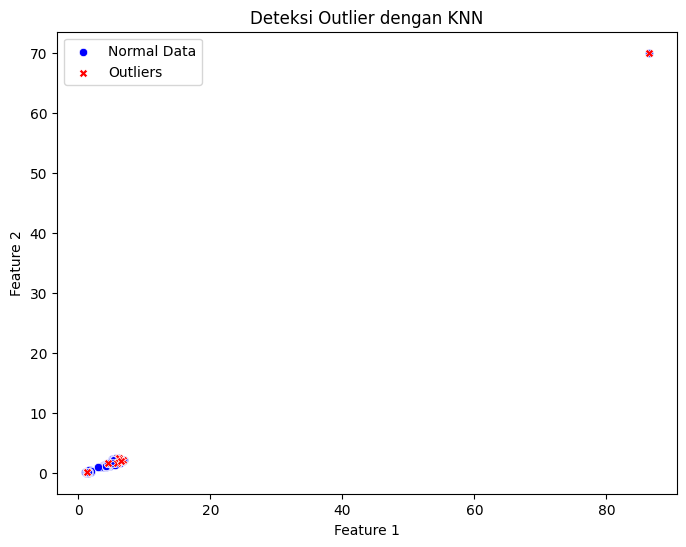

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

# Scatter plot semua data (warna biru)
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], color='blue', label="Normal Data")

# Scatter plot outlier (warna merah)
sns.scatterplot(x=X[df_knn_outlier["is_outlier"] == True].iloc[:, 0],
                y=X[df_knn_outlier["is_outlier"] == True].iloc[:, 1],
                color='red', label="Outliers", marker='X')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Deteksi Outlier dengan KNN")
plt.legend()
plt.show()


#### **Prediksi Class dengan KNN**

Gunakan jarak Euclidean dan voting mayoritas dari K tetangga terdekat.

In [ ]:
import numpy as np

X = df_combined.drop(columns=["id", "Class"])  # Hanya fitur numerik
y = df_combined["Class"]  # Label kelas

def euclidean_distance(row1, row2):
    """Menghitung jarak Euclidean antara dua titik"""
    return np.sqrt(np.sum((row1 - row2) ** 2))

def knn_find_neighbors(X, y, new_data, K=3):
    """
    Menghitung jarak dan memilih K tetangga terdekat.
    """
    distances = []

    # Hitung jarak ke setiap titik dalam dataset
    for i in range(len(X)):
        dist = euclidean_distance(new_data, X.iloc[i])  # Hitung jarak Euclidean
        distances.append((dist, y.iloc[i]))  # Simpan jarak dan kelasnya

    # Urutkan berdasarkan jarak terkecil
    distances.sort(key=lambda x: x[0])

    # Ambil K tetangga terdekat
    return distances[:K]

def knn_classify(neighbors):
    """
    Menentukan kelas berdasarkan mayoritas vote dari K tetangga.
    """
    classes = [neighbor[1] for neighbor in neighbors]  # Ambil kelas dari K tetangga
    predicted_class = max(set(classes), key=classes.count)  # Mayoritas voting
    return predicted_class


Prediksi Kelas untuk Data Baru

In [ ]:
# Data baru yang akan diprediksi (sepal length, sepal width, petal length, petal width)
new_data = np.array([5.8, 2.7, 5.1, 1.9])

# Jalankan KNN untuk mendapatkan K tetangga terdekat
K = 3
neighbors = knn_find_neighbors(X, y, new_data, K)

# Prediksi kelas berdasarkan mayoritas voting
predicted_class = knn_classify(neighbors)

print("Prediksi kelas untuk data baru:", predicted_class)


Prediksi kelas untuk data baru: Iris-virginica


---

# **Local Outlier Factor (LOF)**  

**Local Outlier Factor (LOF)** adalah algoritma deteksi outlier berbasis kepadatan lokal yang membandingkan kepadatan suatu titik dengan kepadatan tetangganya.  

**Konsep utama LOF:**  
- Jika kepadatan lokal suatu titik jauh **lebih rendah** dibandingkan kepadatan tetangganya, maka titik tersebut kemungkinan adalah **outlier**.  
- LOF lebih baik dibandingkan metode global seperti **Z-score atau IQR**, karena mempertimbangkan **distribusi lokal** data.  
- LOF menggunakan **K tetangga terdekat (KNN)** sebagai referensi.  



### **2. Langkah-Langkah Perhitungan LOF**  

LOF dihitung melalui **4 langkah utama**:  


#### **1. Menentukan K Tetangga Terdekat (KNN Distance)**  
Untuk setiap titik **p**, tentukan **K tetangga terdekat** berdasarkan **jarak Euclidean** atau metrik lainnya.  

**Rumus Jarak Euclidean:**  

$d(p, o) = \sqrt{\sum_{i=1}^{n} (p_i - o_i)^2}$

Di mana:  
- **p, o** = dua titik data  
- **d(p, o)** = jarak antara p dan o  
- **n** = jumlah fitur  

**interpretasi**
- Jika **d(p, o) kecil**, maka titik **p** dekat dengan **o** (tetangga).  
- Jika **d(p, o) besar**, maka titik **p** jauh dari **o** (potensi outlier).  



#### **2. Menghitung *Reachability Distance* untuk Setiap Titik**  
Setelah mendapatkan **K tetangga terdekat**, kita menghitung **Reachability Distance** antara **p** dan setiap tetangganya **o**:  

**Rumus Reachability Distance:**  

$
\text{Reachability Distance}(p, o) = \max(\text{K-Distance}(o), d(p, o))
$

Di mana:  
- **K-Distance(o)** = jarak ke **K** tetangga terjauh dari titik **o**  
- **d(p, o)** = jarak langsung antara **p** dan **o**  

**Interpretasi:**  
- Jika titik **p** sangat dekat dengan **o**, tetapi **K-Distance(o) lebih besar**, maka kita gunakan **K-Distance(o)** untuk menjaga skala yang wajar.  



#### **3. Menghitung *Local Reachability Density (LRD)***  
LRD mengukur **kepadatan lokal** suatu titik **p** berdasarkan rata-rata jarak ke tetangganya.  

**Rumus LRD:**  

$
\text{LRD}(p) = \frac{K}{\sum_{o \in KNN(p)} \text{Reachability Distance}(p, o)}
$

Di mana:  
- **K** = jumlah tetangga terdekat  
- **KNN(p)** = daftar **K tetangga** dari **p**  
- **LRD(p)** = seberapa padat titik **p** dibandingkan dengan K tetangganya  

**Interpretasi:**  
- **Jika LRD(p) tinggi** → Titik p berada dalam area padat.  
- **Jika LRD(p) rendah** → Titik p berada di area jarang (kemungkinan outlier).  



### **4. Menghitung *Local Outlier Factor (LOF)***  
LOF dihitung dengan membandingkan **kepadatan tetangga** dengan **kepadatan titik p**.  

**Rumus LOF:**

$
\text{LOF}(p) = \frac{\sum_{o \in KNN(p)} \frac{\text{LRD}(o)}{\text{LRD}(p)}}{K}
$

Di mana:  
- **Jika LOF ≈ 1**, maka **p bukan outlier** (kepadatan p mirip dengan tetangganya).  
- **Jika LOF ≫ 1**, maka **p kemungkinan outlier** (kepadatan p jauh lebih rendah dari tetangganya).  

**Interpretasi:**  
- **LOF < 1** → Titik ini memiliki kepadatan lebih tinggi dibandingkan tetangganya.  
- **LOF mendekati 1** → Titik ini normal.  
- **LOF jauh lebih besar dari 1** → Titik ini **outlier**.  

---
### **CONTOH KASUS**

#### **1. Data Awal**
| ID  | X  | Y  |
|----|----|----|
| 1  | 2.00 | 3.00 |
| 2  | 2.10 | 3.10 |
| 3  | 1.90 | 2.90 |
| 4  | 5.00 | 8.00 |
| 5  | 5.20 | 7.80 |
| 6  | 5.10 | 8.10 |
| 7  | 9.00 | 12.00 |
| 8  | 9.20 | 12.20 |
| 9  | 9.10 | 11.90 |
| 10 | 20.00 | 30.00 |


##### **2. Menghitung Jarak Euclidean**
Jarak Euclidean antara dua titik \((X_1, Y_1)\) dan \((X_2, Y_2)\) dihitung dengan:

$
d(A, B) = \sqrt{(X_1 - X_2)^2 + (Y_1 - Y_2)^2}
$

Setelah perhitungan semua pasangan, buat tabel jarak antar titik:  

| Titik | 1     | 2     | 3     | 4     | 5     | 6     | 7     | 8     | 9     | 10     |
|-------|-------|-------|-------|-------|-------|-------|-------|-------|-------|--------|
| 1     | -     | 0.141 | 0.141 | 5.831 | 5.769 | 5.968 |11.402 |11.682 |11.385 | 32.450 |
| 2     | 0.141 | -     | 0.283 | 5.694 | 5.630 | 5.831 |11.261 |11.542 |11.245 | 32.311 |
| 3     | 0.141 | 0.283 | -     | 5.968 | 5.908 | 6.106 |11.542 |11.823 |11.526 | 32.589 |
| 4     | 5.831 | 5.694 | 5.968 | -     | 0.283 | 0.141 | 5.657 | 5.940 | 5.659 | 26.627 |
| 5     | 5.769 | 5.630 | 5.908 | 0.283 | -     | 0.316 | 5.664 | 5.946 | 5.659 | 26.681 |
| 6     | 5.968 | 5.831 | 6.106 | 0.141 | 0.316 | -     | 5.515 | 5.798 | 5.517 | 26.488 |
| 7     |11.402 |11.261 |11.542 | 5.657 | 5.664 | 5.515 | -     | 0.283 | 0.141 | 21.095 |
| 8     |11.682 |11.542 |11.823 | 5.940 | 5.946 | 5.798 | 0.283 | -     | 0.316 | 20.820 |
| 9     |11.385 |11.245 |11.526 | 5.659 | 5.659 | 5.517 | 0.141 | 0.316 | -     | 21.129 |
| 10    |32.450 |32.311 |32.589 |26.627 |26.681 |26.488 |21.095 |20.820 |21.129 |   -    |



##### **3. Menentukan k-Tetangga Terdekat (k=3)**
Berdasarkan tabel jarak, kita tentukan **3 tetangga terdekat** untuk setiap titik:

| Titik | Tetangga       | 
|-------|----------------|
| 1     | 2, 3, 5        | 
| 2     | 1, 3, 5        | 
| 3     | 1, 2, 5        | 
| 4     | 5, 6, 9        | 
| 5     | 4, 6, 9        | 
| 6     | 4, 5, 7        | 
| 7     | 6, 8, 9        | 
| 8     | 6, 7, 9        | 
| 9     | 6, 7, 8        | 
| 10    | 7, 8, 9        |



##### **4. Menghitung Reachability Distance (RD)**

$
RD(i, j) = max(K-Distance(j), D(i, j))
$

Misalnya untuk **ID 10**:
- **K-Distance(10) = 21.192**
- **RD(10,8) = max(20.820, 5.798) = 20.820**
- **RD(10,7) = max(21.095, 5.515) = 21.095**
- **RD(10,9) = max(21.192, 5.517) = 21.192**



##### **5. Menghitung Local Reachability Density (LRD)**

$$
\text{LRD}(i) = \frac{3}{\sum \text{reach\_dist}(i, j)} \quad \text{untuk } j \in N_k(i)
$$


Misalnya untuk **ID 10**:

$
LRD(10) = \frac{3}{\frac{1}{20.820} + \frac{1}{21.095} + \frac{1}{21.192}}
$

$
= \frac{3}{63.044} = 0.048
$

Lakukan ini untuk semua ID.



##### **6. Menghitung LOF**

$$
\text{LOF}(10) = \frac{1}{|N_k(10)|} \sum_{i \in N_k(10)} \frac{\text{LRD}(i)}{\text{LRD}(10)} = \frac{1}{3} \left( \frac{0.1783}{0.0476} + \frac{0.1783}{0.0476} + \frac{0.1783}{0.0476} \right)
$$


Misalnya untuk **ID 10**:

$$
\text{LOF}(10) = \frac{1}{3} \cdot (3.746 + 3.746 + 3.746) = 3.746
$$


Karena **LOF(10) jauh lebih besar dari 1.5**, maka **ID 10 adalah outlier**.



##### **7. Hasil Akhir Perhitungan LOF untuk Semua Titik**
| Titik | LOF        | Keterangan       |
|-------|------------|------------------|
| 1     | 0.923      | Bukan Outlier    |
| 2     | 0.923      | Bukan Outlier    |
| 3     | 0.923      | Bukan Outlier    |
| 4     | 0.970      | Bukan Outlier    |
| 5     | 0.970      | Bukan Outlier    |
| 6     | 0.970      | Bukan Outlier    |
| 7     | 1.012      | Bukan Outlier    |
| 8     | 1.012      | Bukan Outlier    |
| 9     | 1.012      | Bukan Outlier    |
| 10    | 3.746      | **Outlier**      |


Titik **ID 10 adalah outlier** karena memiliki **LOF jauh di atas 1.5**.  

---


##### **Deteksi outlier menggunakan skylearn**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor

# Data dari tabel
data = {
    "x": [2.00, 2.10, 1.90, 5.00, 5.20, 5.10, 9.00, 9.20, 9.10, 20.00],
    "y": [3.00, 3.10, 2.90, 8.00, 7.80, 8.10, 12.00, 12.20, 11.90, 30.00]
}

df = pd.DataFrame(data)

# Inisialisasi model LOF dengan k=3
lof = LocalOutlierFactor(n_neighbors=3)

# Fit model dan dapatkan skor LOF
df['LOF_Score'] = -lof.fit_predict(df)
df['LOF_Value'] = -lof.negative_outlier_factor_

# Tampilkan hasil
print(df)


      x     y  LOF_Score  LOF_Value
0   2.0   3.0         -1   1.010003
1   2.1   3.1         -1   1.010003
2   1.9   2.9         -1   1.010003
3   5.0   8.0         -1   0.999438
4   5.2   7.8         -1   0.990289
5   5.1   8.1         -1   0.999438
6   9.0  12.0         -1   1.000563
7   9.2  12.2         -1   1.000563
8   9.1  11.9         -1   1.000563
9  20.0  30.0          1   3.745709


### **4. Implementasi LOF Menggunakan `sklearn` pada Data Iris**

**Deteksi outlier menggunakan LOF**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor

# Contoh data: Menggunakan df_combined dari dataset Iris
X = df_combined.drop(columns=['id', 'Class'])  # Hanya fitur numerik

# Inisialisasi model LOF dengan 5 tetangga terdekat
lof = LocalOutlierFactor(n_neighbors=5)

# Prediksi outlier (-1 = outlier, 1 = inlier)
df_combined['LOF_Label'] = lof.fit_predict(X)

# Tambahkan skor LOF ke dataframe
df_combined['LOF_Score'] = lof.negative_outlier_factor_


**Tampilkan Data dengan label**

In [ ]:
# Menampilkan jumlah inlier dan outlier
print("Jumlah inlier dan outlier:")
print(df_combined['LOF_Label'].value_counts())

# Menampilkan  sampel data
print("\nContoh data dengan LOF Label dan Skor:")
print(df_combined.to_string())


Jumlah inlier dan outlier:
LOF_Label
 1    142
-1      8
Name: count, dtype: int64

Contoh data dengan LOF Label dan Skor:
      id            Class  petal length  petal width  sepal length  sepal width  LOF_Label   LOF_Score
0      1      Iris-setosa          86.4         70.0          20.1         30.5         -1 -133.749350
1      2      Iris-setosa           1.4          0.2           4.9          3.0          1   -1.003224
2      3      Iris-setosa           1.3          0.2           4.7          3.2          1   -1.100729
3      4      Iris-setosa           1.5          0.2           4.6          3.1          1   -1.017171
4      5      Iris-setosa           1.4          0.2           5.0          3.6          1   -1.033608
5      6      Iris-setosa           1.7          0.4           5.4          3.9          1   -1.210008
6      7      Iris-setosa           1.4          0.3           4.6          3.4          1   -1.019365
7      8      Iris-setosa           1.5          0.2 

**Visualisasi Outlier dalam Scatter Plot**

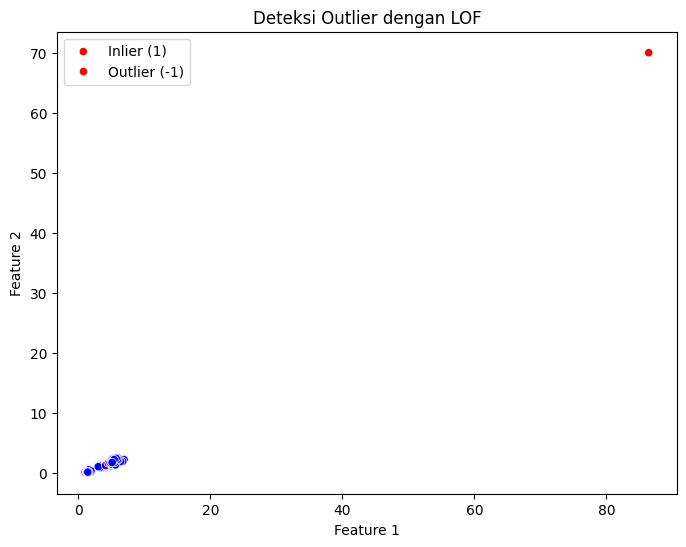

In [ ]:
plt.figure(figsize=(8,6))

# Scatter plot dengan warna sesuai LOF_Label (1 = inlier, -1 = outlier)
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=df_combined['LOF_Label'], palette={1: 'blue', -1: 'red'})

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Deteksi Outlier dengan LOF")
plt.legend(["Inlier (1)", "Outlier (-1)"])
plt.show()
